# 01c — Robustness Check

Test whether LLM results generalize by running the **same model** on a **different 100-loan sample** from the test set.

**Prerequisites:** Generate it first with `python sample_generation.py` (or `get_robustness_batch()`).

**Goal:** Confirm findings from 01a aren't artifacts of the specific sample chosen.

## Setup

In [1]:
# llm_utils.py and llm_pricing.py live one directory up — make them importable.
import sys; sys.path.insert(0, "..")
import os
import pandas as pd
import numpy as np

from llm_utils import (
    load_llm_sample, run_ml_on_sample, run_llm_experiment,
    evaluate_predictions, compare_results, RESULTS_DIR, DATA_DIR
)

In [2]:
FORCE_RERUN = False  # Set to True to re-run API calls from scratch
# ── Configuration ──────────────────────────────────────────────────────────
API_PROVIDER = "openai"
MODEL_NAME   = "gpt-5.4"
LABEL        = "GPT-5.4"
CONDITIONS   = [False, True]   # no_desc, with_desc

from llm_utils import load_all_api_keys
API_KEYS = load_all_api_keys(API_PROVIDER)
MAX_WORKERS = max(1, len(API_KEYS) * 4)

## Load Pre-Sampled Batch

In [3]:
# Load the robustness batch (generated by sample_generation.get_robustness_batch)
new_sample_path = f"{DATA_DIR}/robustness_batch.csv"
assert os.path.exists(new_sample_path), (
    f"New batch CSV not found at {new_sample_path}.\n"
    "Generate it first: python sample_generation.py (or get_robustness_batch())."
)
new_sample = pd.read_csv(new_sample_path)

# Load original sample for comparison
original_sample = load_llm_sample()

print(f"Original sample: {len(original_sample)} loans")
print(f"New sample:      {len(new_sample)} loans")
print(f"\nNew sample class distribution:")
print(new_sample['loan_status'].value_counts())
print(f"\nOriginal sample class distribution:")
print(original_sample['loan_status'].value_counts())

Original sample: 100 loans
New sample:      100 loans

New sample class distribution:
loan_status
1    91
0     9
Name: count, dtype: int64

Original sample class distribution:
loan_status
1    85
0    15
Name: count, dtype: int64


## Run XGBoost & LLM on New Sample

In [4]:
# XGBoost on new sample
xgb_probs_new, xgb_preds_new = run_ml_on_sample(new_sample)
y_true_new = new_sample['loan_status'].values

print(f"XGBoost predictions ready: {len(xgb_preds_new)} samples")

XGBoost predictions ready: 100 samples


In [5]:
# LLM on new sample — both conditions in parallel
from concurrent.futures import ThreadPoolExecutor, as_completed

tasks = {}
results_by_cond = {}

with ThreadPoolExecutor(max_workers=2) as pool:
    for inc_desc in CONDITIONS:
        cond_tag = 'with_desc' if inc_desc else 'no_desc'
        future = pool.submit(
            run_llm_experiment,
            new_sample,
            api_provider=API_PROVIDER,
            model_name=MODEL_NAME,
            include_desc=inc_desc,
            label=f"{LABEL} | {cond_tag} | new batch",
            api_keys=API_KEYS,
            max_workers=MAX_WORKERS,
        )
        tasks[future] = cond_tag

    for future in as_completed(tasks):
        cond_tag = tasks[future]
        results_by_cond[cond_tag] = future.result()
        acc = results_by_cond[cond_tag]['metrics']['accuracy']
        print(f"\n✓ {cond_tag} done — accuracy: {acc*100:.1f}%")

print(f"\nAll runs complete.")

[GPT-5.4 | with_desc | new batch | with_desc] First call OK (pred=0, prob=0.0). Running 100 loans on 10 key(s) × 40 worker(s)...
[GPT-5.4 | no_desc | new batch | no_desc] First call OK (pred=0, prob=0.0). Running 100 loans on 10 key(s) × 40 worker(s)...
[GPT-5.4 | with_desc | new batch | with_desc] 26/100 done (4s elapsed, ~11s remaining)
[GPT-5.4 | no_desc | new batch | no_desc] 26/100 done (4s elapsed, ~11s remaining)
[GPT-5.4 | with_desc | new batch | with_desc] 51/100 done (6s elapsed, ~6s remaining)
[GPT-5.4 | no_desc | new batch | no_desc] 51/100 done (6s elapsed, ~6s remaining)
[GPT-5.4 | with_desc | new batch | with_desc] 76/100 done (8s elapsed, ~2s remaining)
[GPT-5.4 | no_desc | new batch | no_desc] 76/100 done (8s elapsed, ~3s remaining)
[GPT-5.4 | no_desc | new batch | no_desc] 100/100 done (12s elapsed, ~0s remaining)
[GPT-5.4 | no_desc | new batch | no_desc] COMPLETE — 100 predictions, 0 parse errors, 100 with logprobs, 12s total

GPT-5.4 | no_desc | new batch (no_desc) 

## Compare: Original vs New Batch

In [6]:
# Load original results from 01a
original_metrics_path = f"{RESULTS_DIR}/01a_metrics.csv"
if os.path.exists(original_metrics_path):
    orig_metrics = pd.read_csv(original_metrics_path, index_col=[0, 1])
    print("Original sample results (from 01a):")
    print(orig_metrics.to_string())
else:
    print("01a results not found — run 01a first for comparison")

# New sample results
xgb_metrics_new = evaluate_predictions(y_true_new, xgb_preds_new.tolist(), label="XGBoost (new batch)")

print(f"\n{'='*60}")
print(f"Side-by-side: Original (01a) vs New Batch")
print(f"{'='*60}")

comparison_rows = [
    {'batch': 'New', 'model': 'XGBoost', 'condition': '-', **xgb_metrics_new},
]
for cond_tag, res in sorted(results_by_cond.items()):
    comparison_rows.append({
        'batch': 'New', 'model': LABEL, 'condition': cond_tag, **res['metrics']
    })

new_df = pd.DataFrame(comparison_rows)
print(new_df.to_string(index=False))

Original sample results (from 01a):
                              accuracy  precision_charged_off  recall_charged_off  f1_charged_off       auc  n_valid
model             condition                                                                                         
XGBoost           structured  0.650000               0.205882            0.466667        0.285714       NaN      100
GPT-5.4           no_desc     0.810000               0.375000            0.400000        0.387097  0.624314      100
                  with_desc   0.780000               0.315789            0.400000        0.352941  0.617255      100
Claude Opus 4.8   no_desc     0.670000               0.218750            0.466667        0.297872       NaN      100
                  with_desc   0.690000               0.233333            0.466667        0.311111       NaN      100
Claude Sonnet 4.6 with_desc   0.500000               0.169811            0.600000        0.264706       NaN      100
Gemini 3.5 Flash  no_desc   

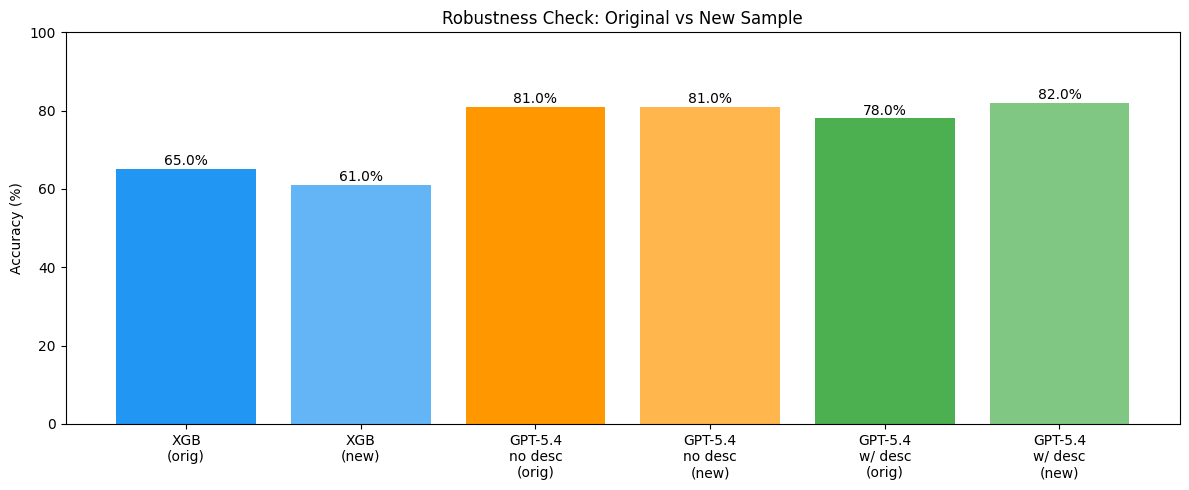

In [7]:
import matplotlib.pyplot as plt

# Visual comparison if 01a results exist
if os.path.exists(original_metrics_path):
    orig = orig_metrics.reset_index()

    labels = ['XGB\n(orig)', 'XGB\n(new)']
    accuracies = [
        orig[orig['model'] == 'XGBoost']['accuracy'].values[0] if len(orig[orig['model'] == 'XGBoost']) else 0,
        xgb_metrics_new['accuracy'],
    ]
    colors = ['#2196F3', '#64B5F6']

    for cond_tag in ['no_desc', 'with_desc']:
        orig_llm = orig[(orig['model'] == LABEL) & (orig['condition'] == cond_tag)]
        tag_short = 'no desc' if cond_tag == 'no_desc' else 'w/ desc'
        labels.append(f'{LABEL}\n{tag_short}\n(orig)')
        accuracies.append(orig_llm['accuracy'].values[0] if len(orig_llm) else 0)
        colors.append('#FF9800' if cond_tag == 'no_desc' else '#4CAF50')

        labels.append(f'{LABEL}\n{tag_short}\n(new)')
        accuracies.append(results_by_cond[cond_tag]['metrics']['accuracy'])
        colors.append('#FFB74D' if cond_tag == 'no_desc' else '#81C784')

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(labels, [a * 100 for a in accuracies], color=colors)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Robustness Check: Original vs New Sample')
    ax.set_ylim(0, 100)
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc*100:.1f}%', ha='center')
    plt.tight_layout()
    plt.show()

## Export Results

In [8]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save consolidated per-condition predictions + reasoning into one file.
# Per-loan tokens/cost are embedded so cost is derivable from this file alone.
all_predictions = []
for cond_tag, res in results_by_cond.items():
    comparison = compare_results(
        y_true_new, res['predictions'], xgb_preds_new.tolist(), res['reasonings'],
        input_tokens=res.get('input_tokens'),
        output_tokens=res.get('output_tokens'),
        cost_usd=res.get('cost_usd'),
    )
    comparison.insert(0, 'desc_tag', cond_tag)
    all_predictions.append(comparison)

pd.concat(all_predictions, ignore_index=True).to_csv(
    f"{RESULTS_DIR}/01c_predictions.csv", index=False
)

# Save combined metrics
all_rows = [{'batch': 'New', 'model': 'XGBoost', 'condition': '-', **xgb_metrics_new}]
for cond_tag, res in sorted(results_by_cond.items()):
    all_rows.append({'batch': 'New', 'model': LABEL, 'condition': cond_tag, **res['metrics']})

pd.DataFrame(all_rows).to_csv(f"{RESULTS_DIR}/01c_metrics.csv", index=False)

print(f"Results saved to {RESULTS_DIR}/")

Results saved to /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/
